# 🧹 Customer Support Ticket — Data Cleaning & EDA

**Dataset:** `raw.csv` — 28,587 support tickets with subject, body, answer, type, queue, priority, language, version, and tag columns.

**Goals:**
1. Merge `subject` + `body` into a single `text` field
2. Keep only the columns needed downstream: `text`, `answer`, `type`, `queue`
3. Full Exploratory Data Analysis (EDA) — distributions, text statistics, correlations, word clouds

## 0. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Consistent dark aesthetic ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1d27',
    'axes.edgecolor':    '#2e3250',
    'axes.labelcolor':   '#c8ccd8',
    'axes.titlecolor':   '#ffffff',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#8b90a8',
    'ytick.color':       '#8b90a8',
    'text.color':        '#c8ccd8',
    'grid.color':        '#2e3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        130,
})

# Palette
PALETTE = ['#7c6af7', '#5ddcf5', '#f76c6c', '#f7c948', '#56e39f',
           '#ff8f6b', '#c46af7', '#6af7c4', '#f76ca8', '#a8f76c']

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Raw Data

In [2]:
RAW_PATH    = Path('raw.csv')
CLEAN_PATH  = Path('clean.csv')

df_raw = pd.read_csv(RAW_PATH)

print(f'Shape        : {df_raw.shape}')
print(f'Columns      : {df_raw.columns.tolist()}')
print(f'Memory usage : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_raw.head(3)

Shape        : (28587, 16)
Columns      : ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Memory usage : 47.9 MB


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

### 2.1 Merge subject + body → text

In [3]:
def merge_subject_body(row):
    """Merge subject and body into a single text field separated by a newline."""
    parts = []
    if pd.notna(row['subject']) and str(row['subject']).strip():
        parts.append(str(row['subject']).strip())
    if pd.notna(row['body']) and str(row['body']).strip():
        parts.append(str(row['body']).strip())
    return '\n'.join(parts)


df_raw['text'] = df_raw.apply(merge_subject_body, axis=1)

# Quick sanity check
sample = df_raw[['subject', 'body', 'text']].dropna(subset=['text']).iloc[0]
print('=== Subject ===')
print(sample['subject'])
print('\n=== Body (first 200 chars) ===')
print(str(sample['body'])[:200])
print('\n=== Merged text (first 300 chars) ===')
print(sample['text'][:300])

=== Subject ===
Wesentlicher Sicherheitsvorfall

=== Body (first 200 chars) ===
Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bild

=== Merged text (first 300 chars) ===
Wesentlicher Sicherheitsvorfall
Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für di


### 2.2 Keep required columns only

In [4]:
KEEP_COLS = ['text', 'answer', 'type', 'queue']
df = df_raw[KEEP_COLS].copy()
print(f'Columns kept : {df.columns.tolist()}')
print(f'Shape        : {df.shape}')

Columns kept : ['text', 'answer', 'type', 'queue']
Shape        : (28587, 4)


### 2.3 Null & duplicate audit

In [5]:
null_summary = pd.DataFrame({
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
})
print(null_summary)

dupe_count = df.duplicated(subset='text').sum()
print(f'\nDuplicate texts : {dupe_count} ({dupe_count/len(df)*100:.2f}%)')

        nulls  null_% dtype
text        0    0.00   str
answer      7    0.02   str
type        0    0.00   str
queue       0    0.00   str

Duplicate texts : 0 (0.00%)


### 2.4 Drop rows with empty text or missing label columns

In [6]:
before = len(df)

# Drop empty text
df = df[df['text'].str.strip().astype(bool)].copy()

# Drop rows missing key label columns
df = df.dropna(subset=['type', 'queue']).copy()

# Drop exact duplicate texts
df = df.drop_duplicates(subset='text').copy()

# Reset index
df = df.reset_index(drop=True)

after = len(df)
print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Dropped     : {before - after:,} ({(before - after) / before * 100:.2f}%)')

Rows before : 28,587
Rows after  : 28,587
Dropped     : 0 (0.00%)


### 2.5 Clean text — strip HTML/email artefacts

In [7]:
def clean_text(text: str) -> str:
    """Lightweight cleaning: strip HTML tags, excessive whitespace."""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Collapse multiple newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    # Collapse multiple spaces
    text = re.sub(r'[ \t]{2,}', ' ', text)
    # Strip leading/trailing whitespace
    return text.strip()


df['text'] = df['text'].apply(clean_text)

# Strip category labels
for col in ['type', 'queue']:
    df[col] = df[col].str.strip()

print('Text cleaning done ✅')
print(df.head(2)[['text', 'type', 'queue']].to_string())

Text cleaning done ✅
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               text      type              queue
0  Wesentlicher Sicherheitsvorfall\nSehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten un

### 2.6 Save cleaned data

In [8]:
df.to_csv(CLEAN_PATH, index=False)
print(f'Saved → {CLEAN_PATH}  ({len(df):,} rows)')
df.head()

Saved → clean.csv  (28,587 rows)


,text,answer,type,queue
0,Wesentlicher Sicherheitsvorfall\nSehr geehrtes...,Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support
1,Account Disruption\nDear Customer Support Team...,"Thank you for reaching out, <name>. We are awa...",Incident,Technical Support
2,Query About Smart Home System Integration Feat...,Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges
3,Inquiry Regarding Invoice Details\nDear Custom...,We appreciate you reaching out with your billi...,Request,Billing and Payments
4,Question About Marketing Agency Software Compa...,Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Class distribution — `type` & `queue`

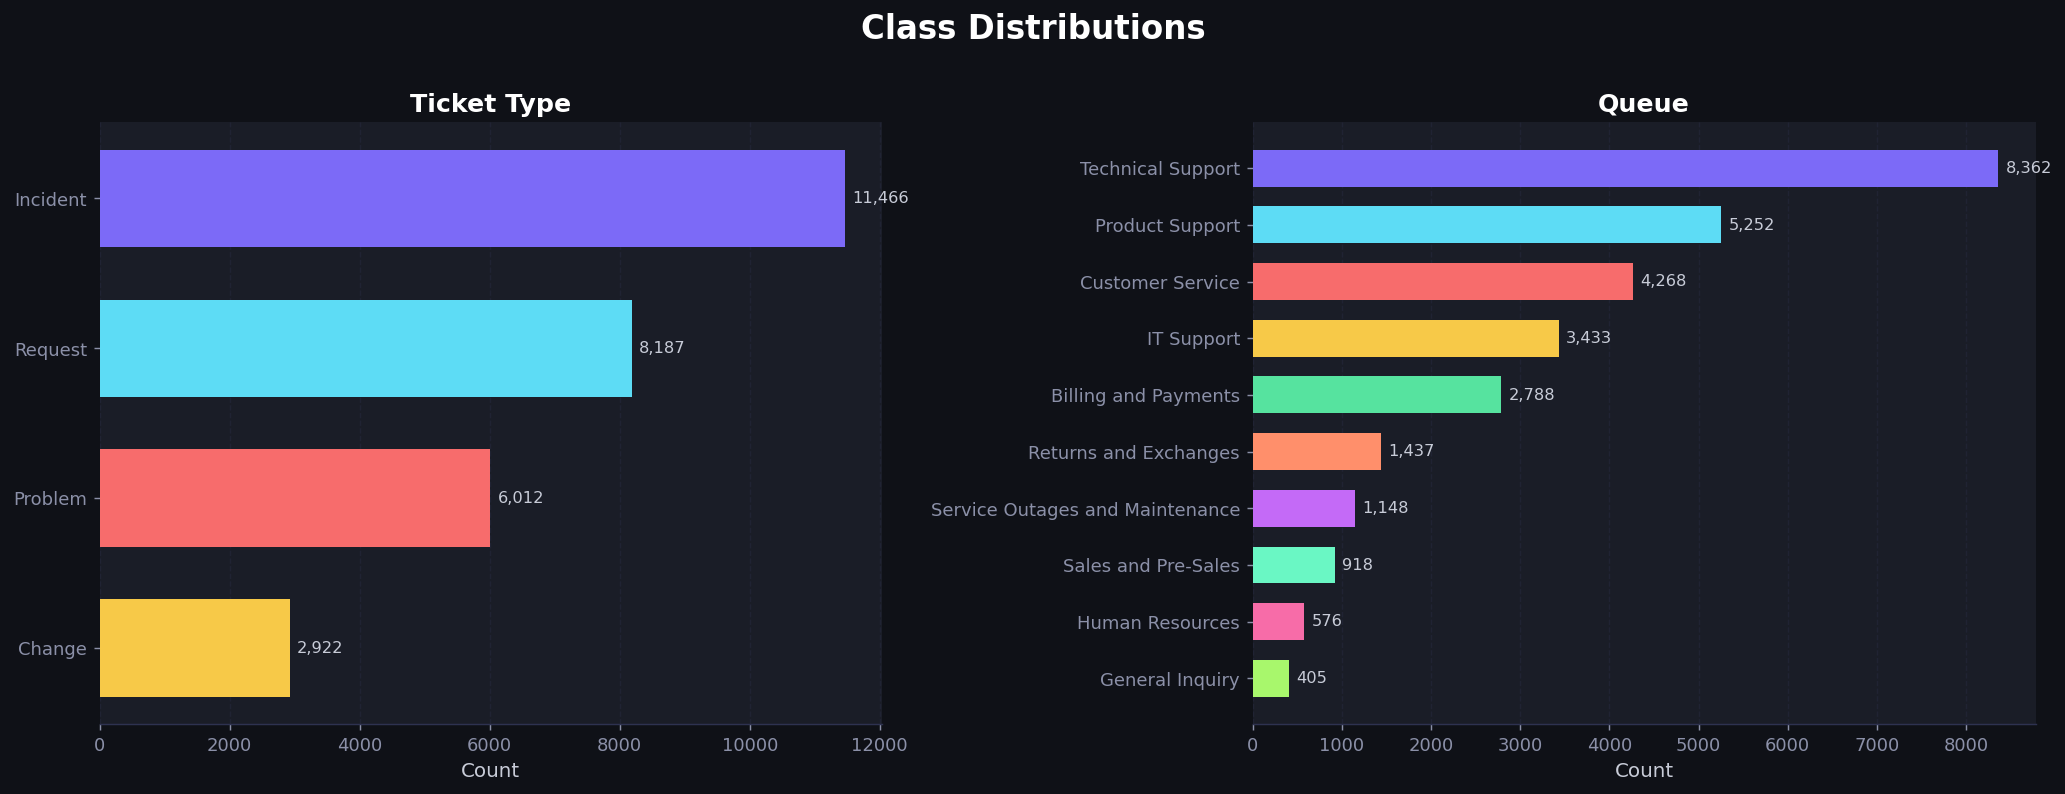

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Distributions', fontsize=18, fontweight='bold', color='white', y=1.01)

for ax, col, title in zip(axes, ['type', 'queue'], ['Ticket Type', 'Queue']):
    vc = df[col].value_counts()
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vc))]
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=colors[::-1],
                   edgecolor='none', height=0.65)

    # Value labels
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + max(vc.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9, color='#c8ccd8')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.3 Text length distributions (violin + box)

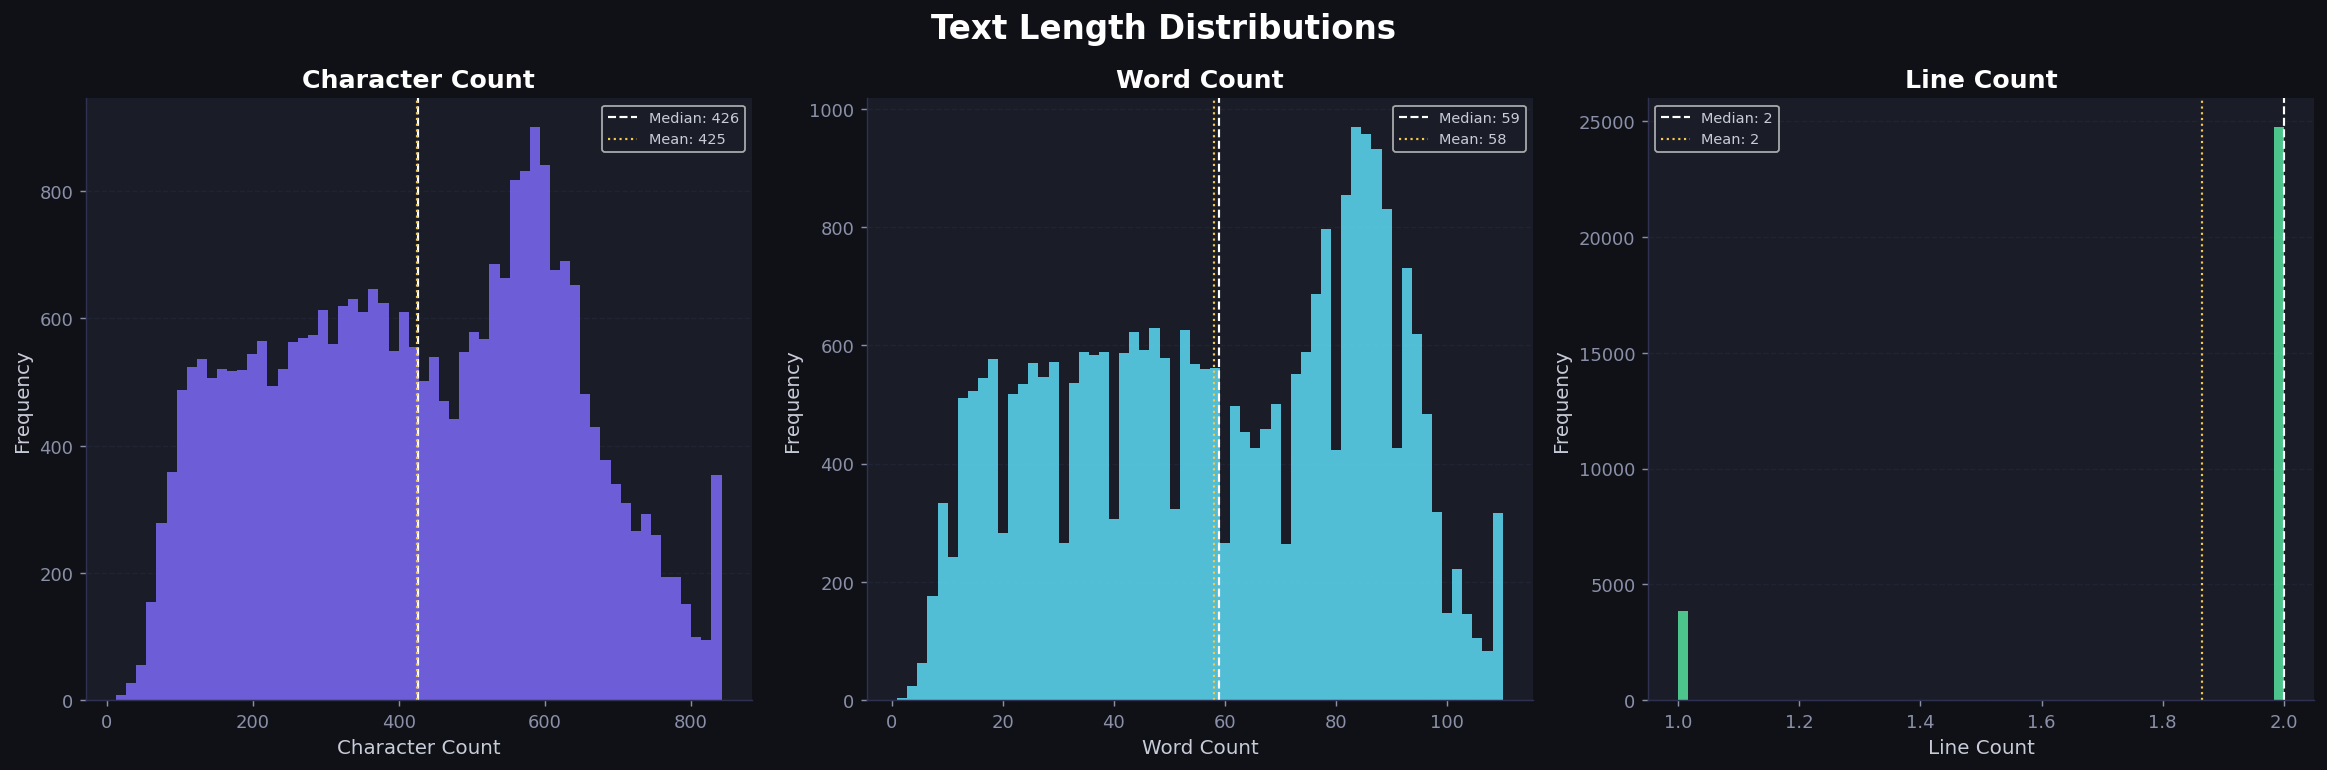

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Text Length Distributions', fontsize=18, fontweight='bold', color='white')

metrics = [
    ('char_len', 'Character Count', '#7c6af7'),
    ('word_len', 'Word Count',      '#5ddcf5'),
    ('line_len', 'Line Count',      '#56e39f'),
]

for ax, (col, label, color) in zip(axes, metrics):
    # Clip at 99th percentile for readability
    cap = df[col].quantile(0.99)
    data = df[col].clip(upper=cap)

    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.median(), color='white', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.0f}')
    ax.axvline(data.mean(), color='#f7c948', linestyle=':', linewidth=1.2,
               label=f'Mean: {data.mean():.0f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_02_text_length_dist.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.4 Word count by `type` and `queue` (violin plots)

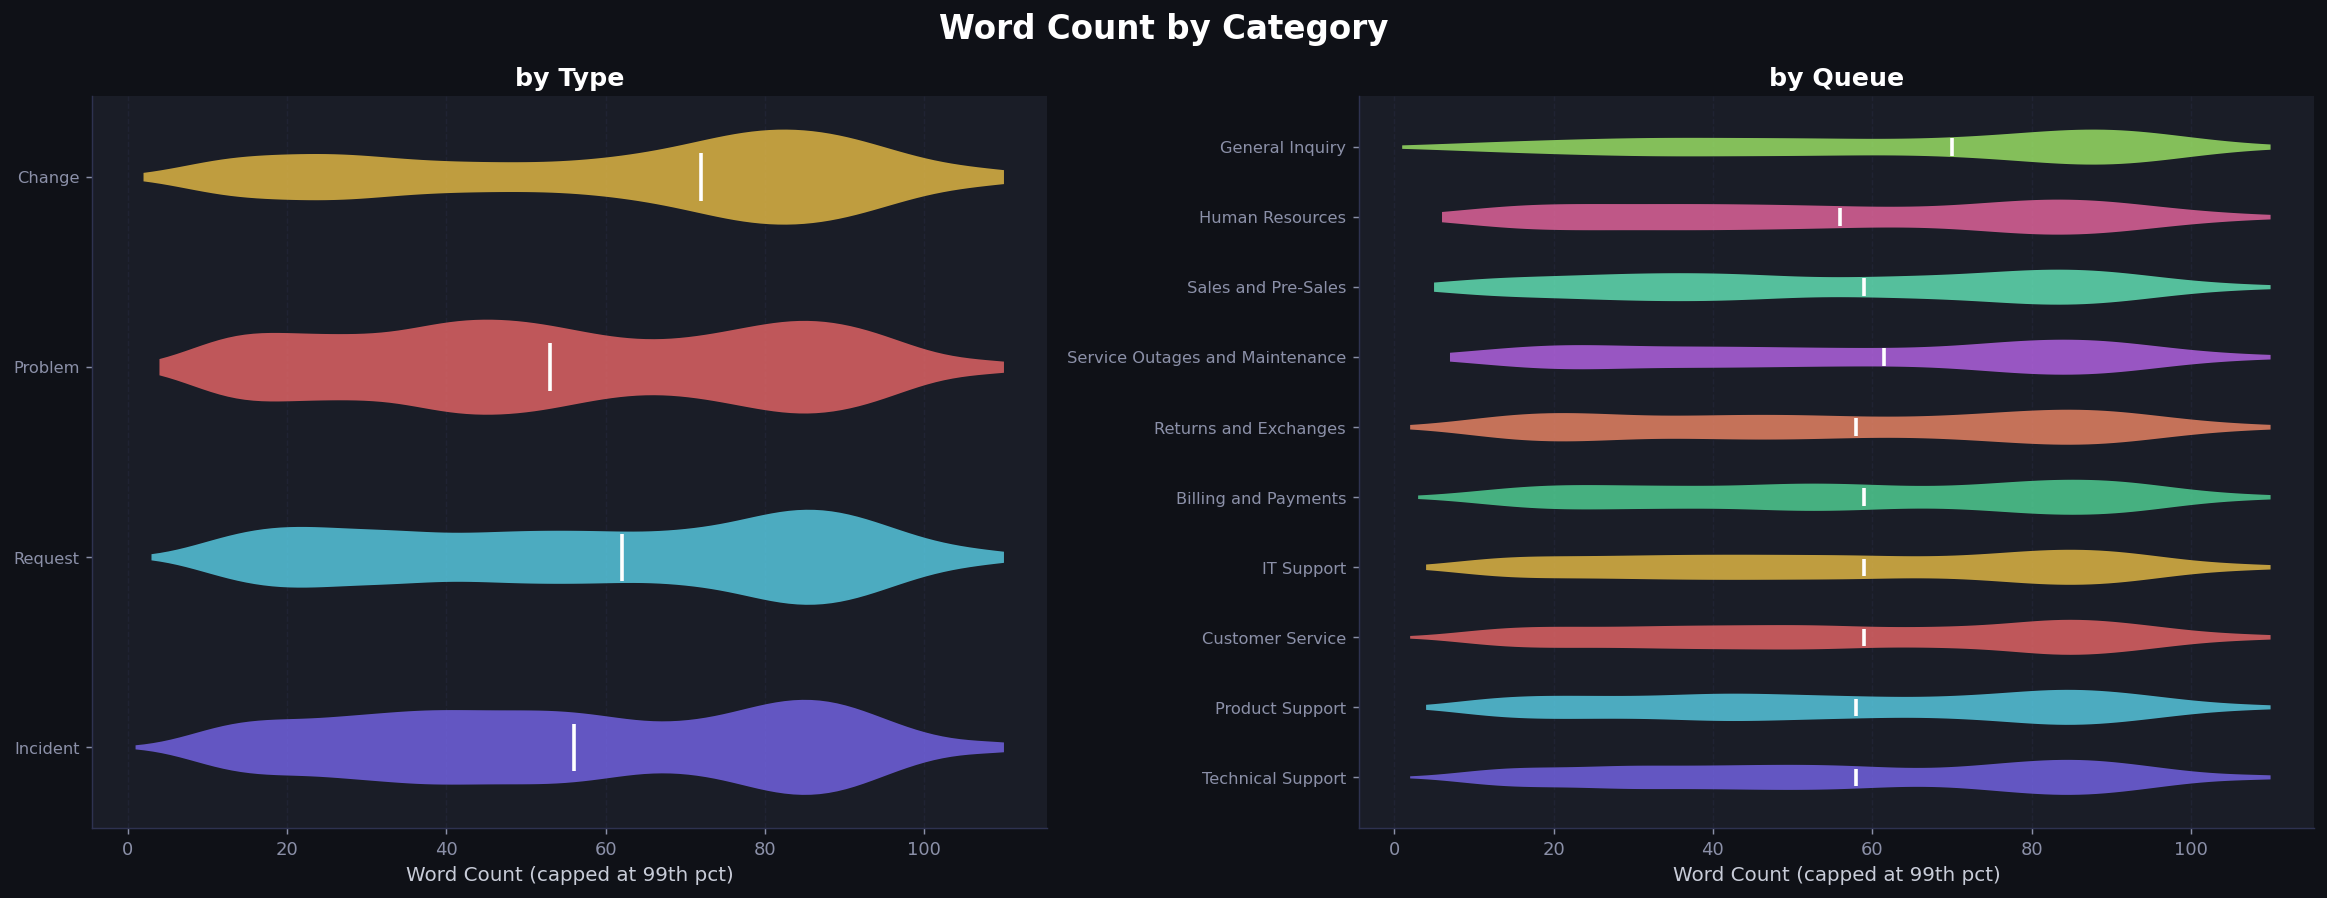

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Count by Category', fontsize=18, fontweight='bold', color='white')

for ax, col, title in zip(axes, ['type', 'queue'], ['by Type', 'by Queue']):
    categories = df[col].value_counts().index.tolist()
    data_groups = [df.loc[df[col] == c, 'word_len'].clip(upper=df['word_len'].quantile(0.99)).values
                   for c in categories]

    parts = ax.violinplot(data_groups, vert=False, showmedians=True, showextrema=False)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PALETTE[i % len(PALETTE)])
        pc.set_alpha(0.75)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    ax.set_yticks(range(1, len(categories) + 1))
    ax.set_yticklabels(categories, fontsize=9)
    ax.set_xlabel('Word Count (capped at 99th pct)')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_03_wordcount_by_category.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.5 Answer availability & length

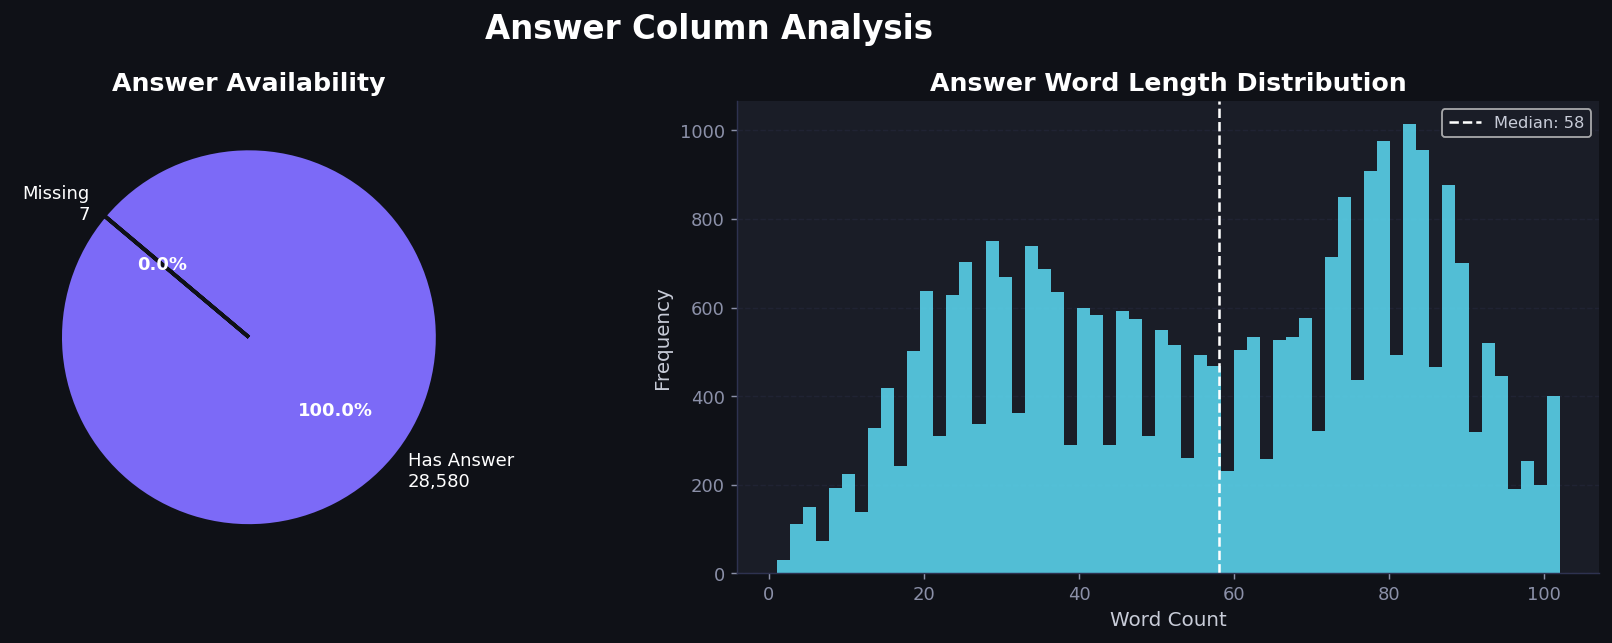

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Answer Column Analysis', fontsize=18, fontweight='bold', color='white')

# — Pie: has answer vs missing —
has_answer = df['answer'].notna().sum()
no_answer  = df['answer'].isna().sum()
sizes  = [has_answer, no_answer]
labels = [f'Has Answer\n{has_answer:,}', f'Missing\n{no_answer:,}']
wedge_colors = [PALETTE[0], PALETTE[2]]

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=wedge_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white')
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Answer Availability', fontweight='bold')

# — Histogram: answer word length —
ans_words = df['answer'].dropna().apply(lambda x: len(str(x).split()))
cap = ans_words.quantile(0.99)
axes[1].hist(ans_words.clip(upper=cap), bins=60, color=PALETTE[1], alpha=0.85, edgecolor='none')
axes[1].axvline(ans_words.median(), color='white', linestyle='--', linewidth=1.4,
                label=f'Median: {ans_words.median():.0f}')
axes[1].set_title('Answer Word Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_04_answer_analysis.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.6 Heatmap — ticket counts: type × queue

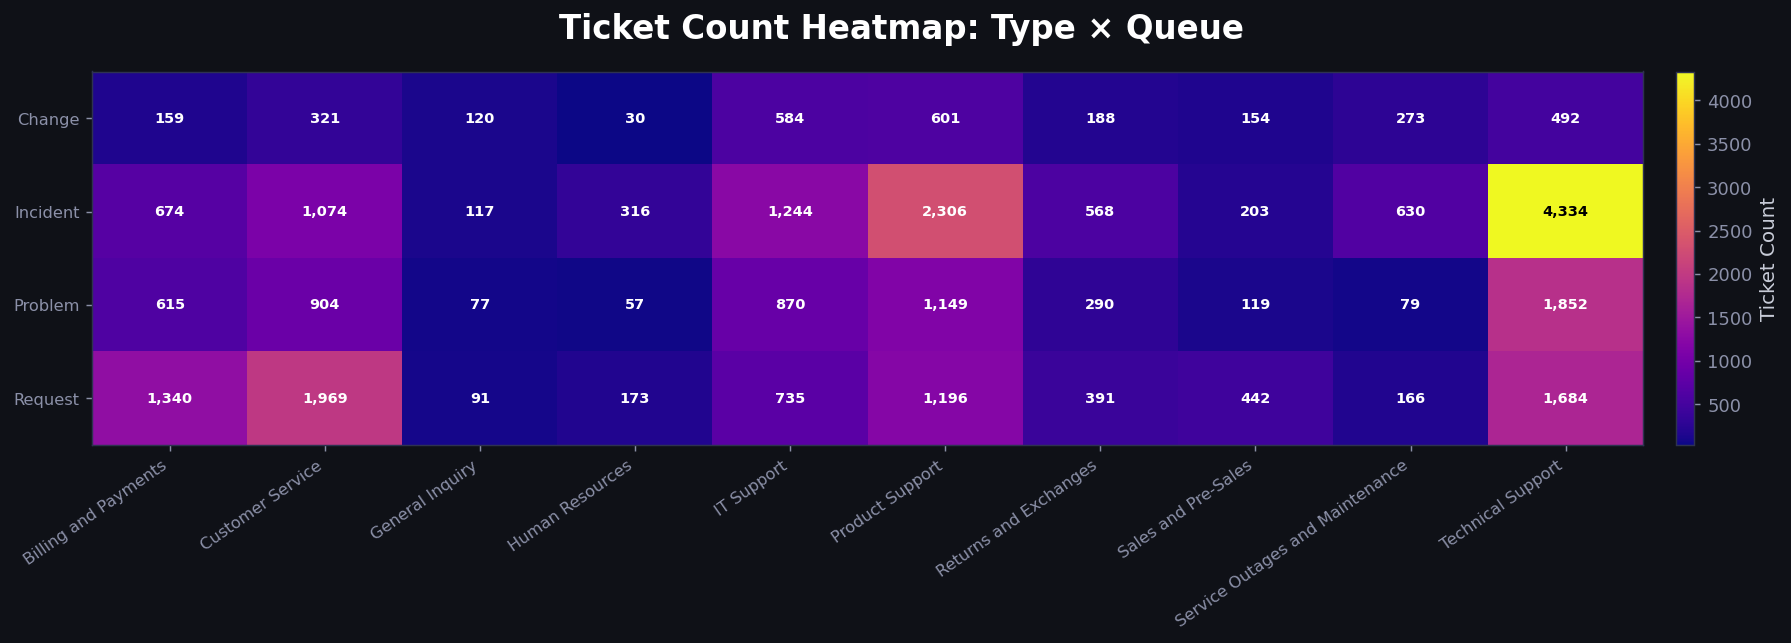

queue,Billing and Payments,Customer Service,General Inquiry,Human Resources,IT Support,Product Support,Returns and Exchanges,Sales and Pre-Sales,Service Outages and Maintenance,Technical Support
type,,,,,,,,,,
Change,159,321,120,30,584,601,188,154,273,492
Incident,674,1074,117,316,1244,2306,568,203,630,4334
Problem,615,904,77,57,870,1149,290,119,79,1852
Request,1340,1969,91,173,735,1196,391,442,166,1684


In [14]:
pivot = df.groupby(['type', 'queue']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, max(5, len(pivot) * 0.7)))
fig.suptitle('Ticket Count Heatmap: Type × Queue', fontsize=18, fontweight='bold', color='white')

# Manual color scale using imshow
im = ax.imshow(pivot.values, aspect='auto', cmap='plasma')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Annotate cells
vmax = pivot.values.max()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        text_color = 'black' if val > vmax * 0.6 else 'white'
        ax.text(j, i, f'{val:,}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Ticket Count')
plt.tight_layout()
plt.savefig('eda_05_heatmap_type_queue.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()
display(pivot)

### 3.7 Top N-grams per class (type)

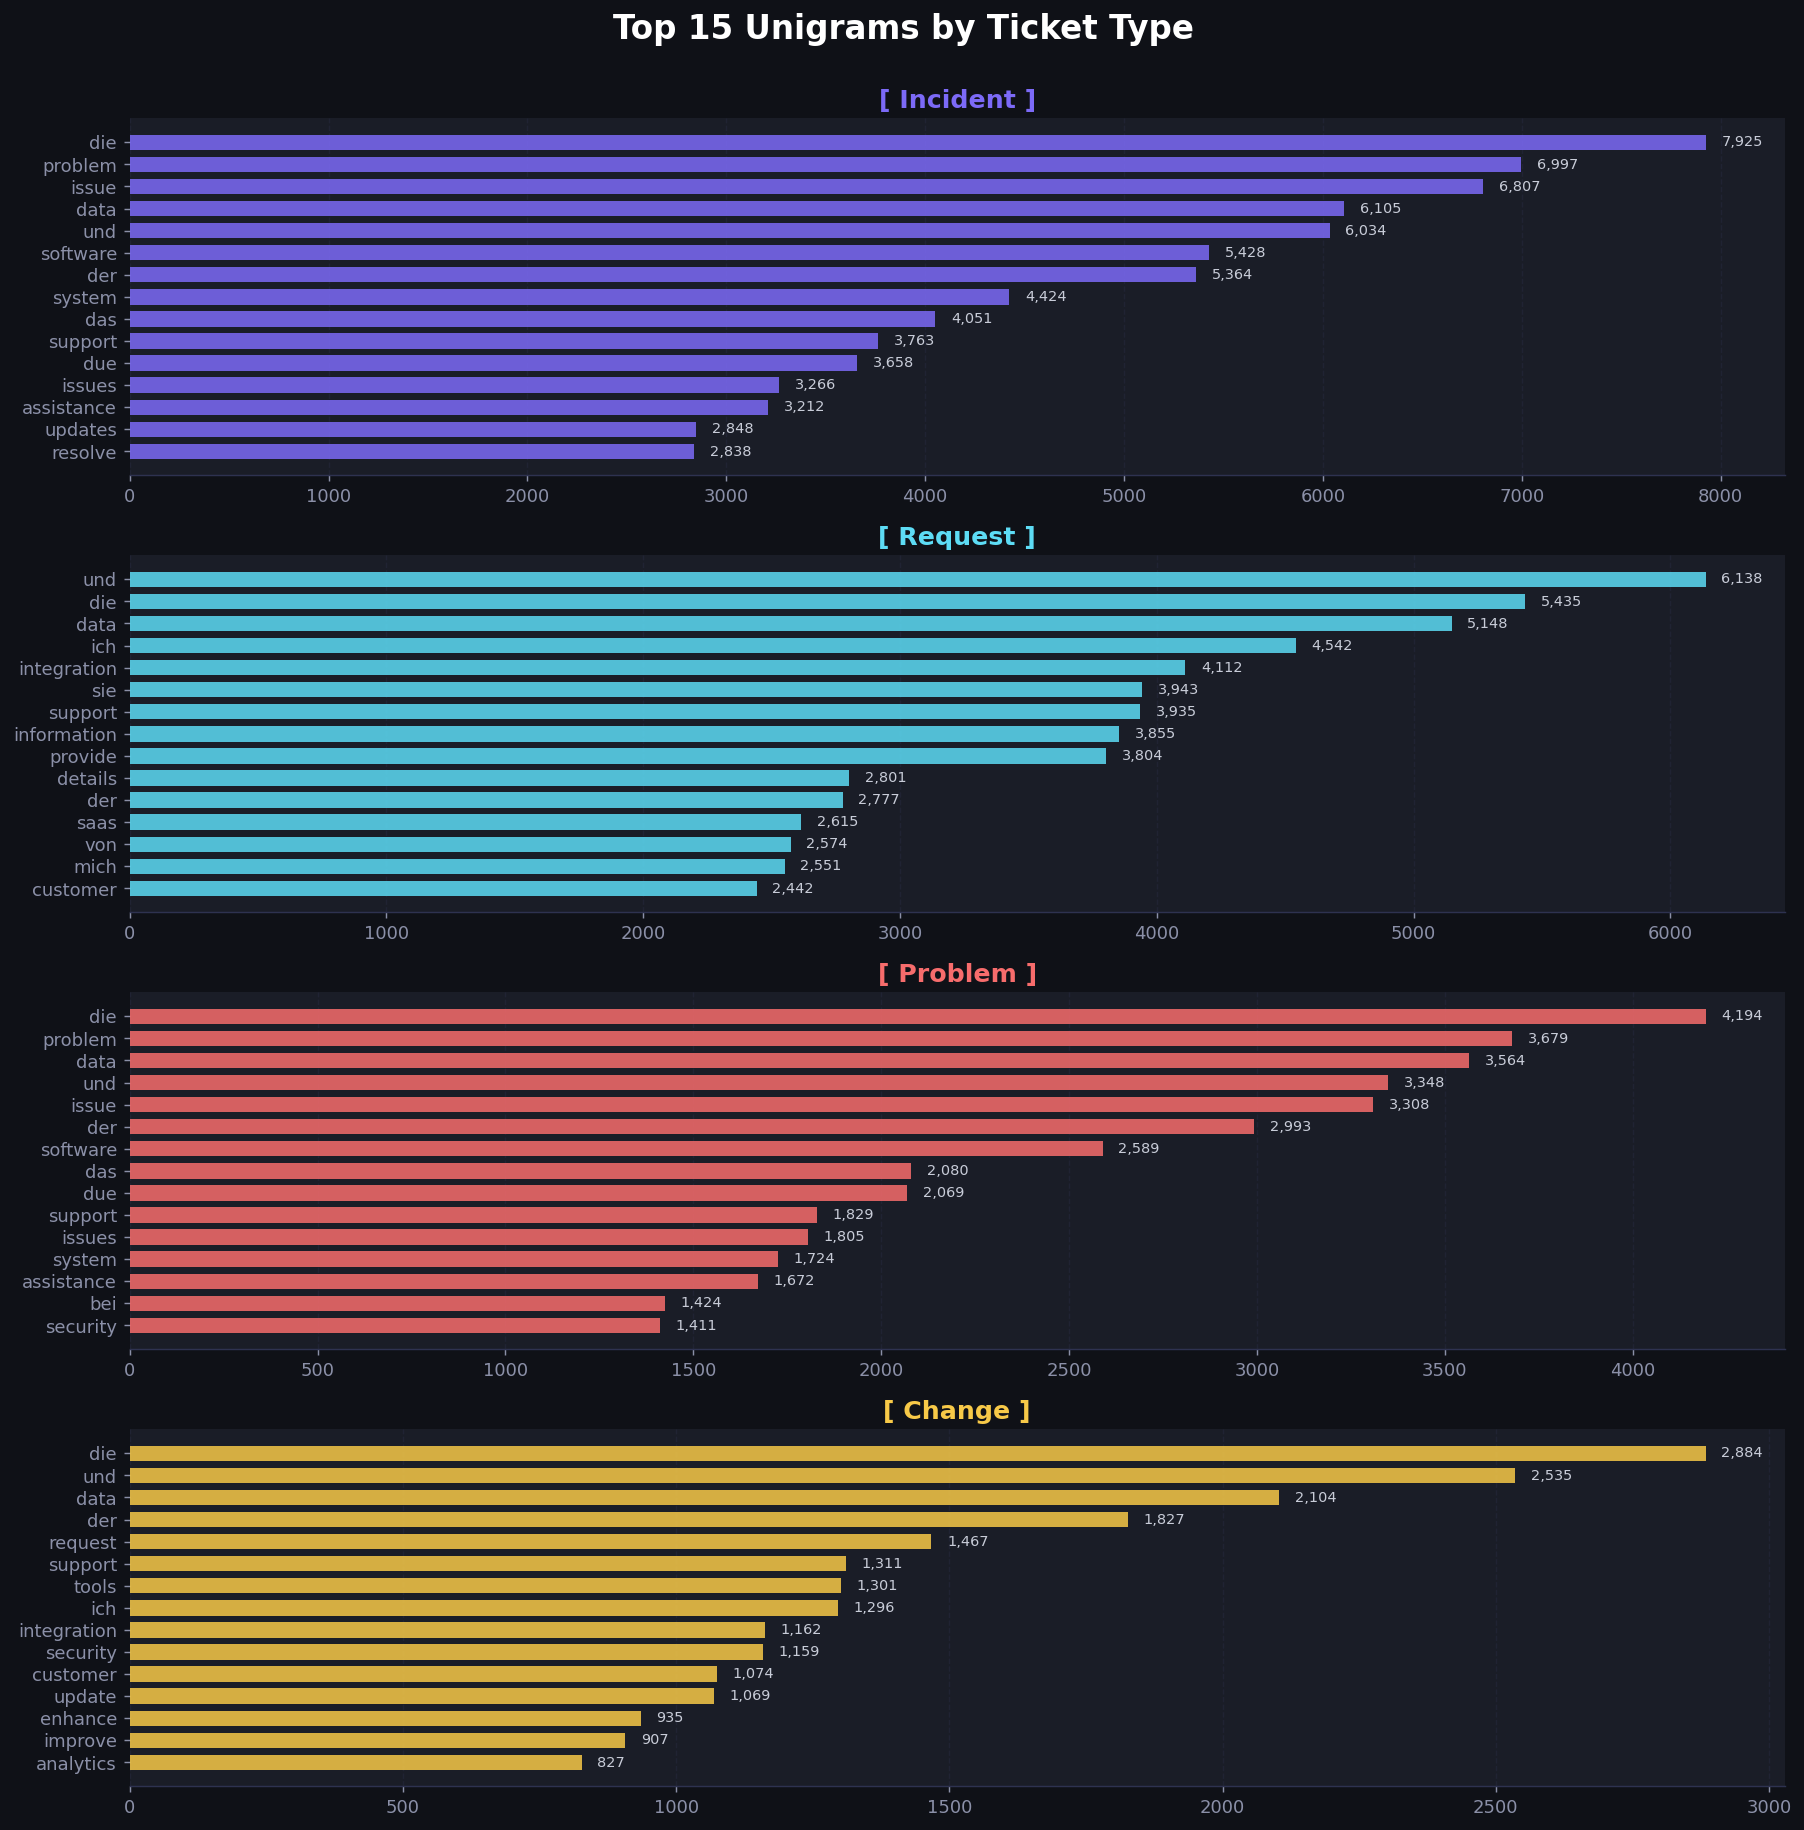

In [15]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','have','has','had','will','would',
    'could','should','may','might','do','does','did','not','no','we','i',
    'you','he','she','they','it','this','that','our','your','my','re','s',
    'can','from','by','as','if','so','am','hi','hello','dear','please',
    'thank','thanks','regards','get','us','me','all','up','out','there',
    'about','just','also','more','than','any','which','ve','ll','don','t',
}

def top_ngrams(texts, n=1, top_k=15):
    tokens = []
    for text in texts:
        words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        words = [w for w in words if w not in STOPWORDS]
        if n == 1:
            tokens.extend(words)
        else:
            tokens.extend([' '.join(words[i:i+n]) for i in range(len(words)-n+1)])
    return Counter(tokens).most_common(top_k)


ticket_types = df['type'].value_counts().index.tolist()
n_types = len(ticket_types)

fig, axes = plt.subplots(n_types, 1, figsize=(14, n_types * 3.5))
if n_types == 1:
    axes = [axes]
fig.suptitle('Top 15 Unigrams by Ticket Type', fontsize=18, fontweight='bold', color='white', y=1.002)

for ax, t_type, color in zip(axes, ticket_types, PALETTE):
    subset = df[df['type'] == t_type]['text']
    ngrams = top_ngrams(subset, n=1, top_k=15)
    if not ngrams:
        ax.set_visible(False)
        continue
    words, counts = zip(*ngrams)

    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='none', height=0.7)

    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{cnt:,}', va='center', fontsize=8, color='#c8ccd8')

    ax.set_title(f'[ {t_type} ]', fontweight='bold', color=color)
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_06_top_ngrams_by_type.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.9 Cumulative text length by class (Lorenz-style)

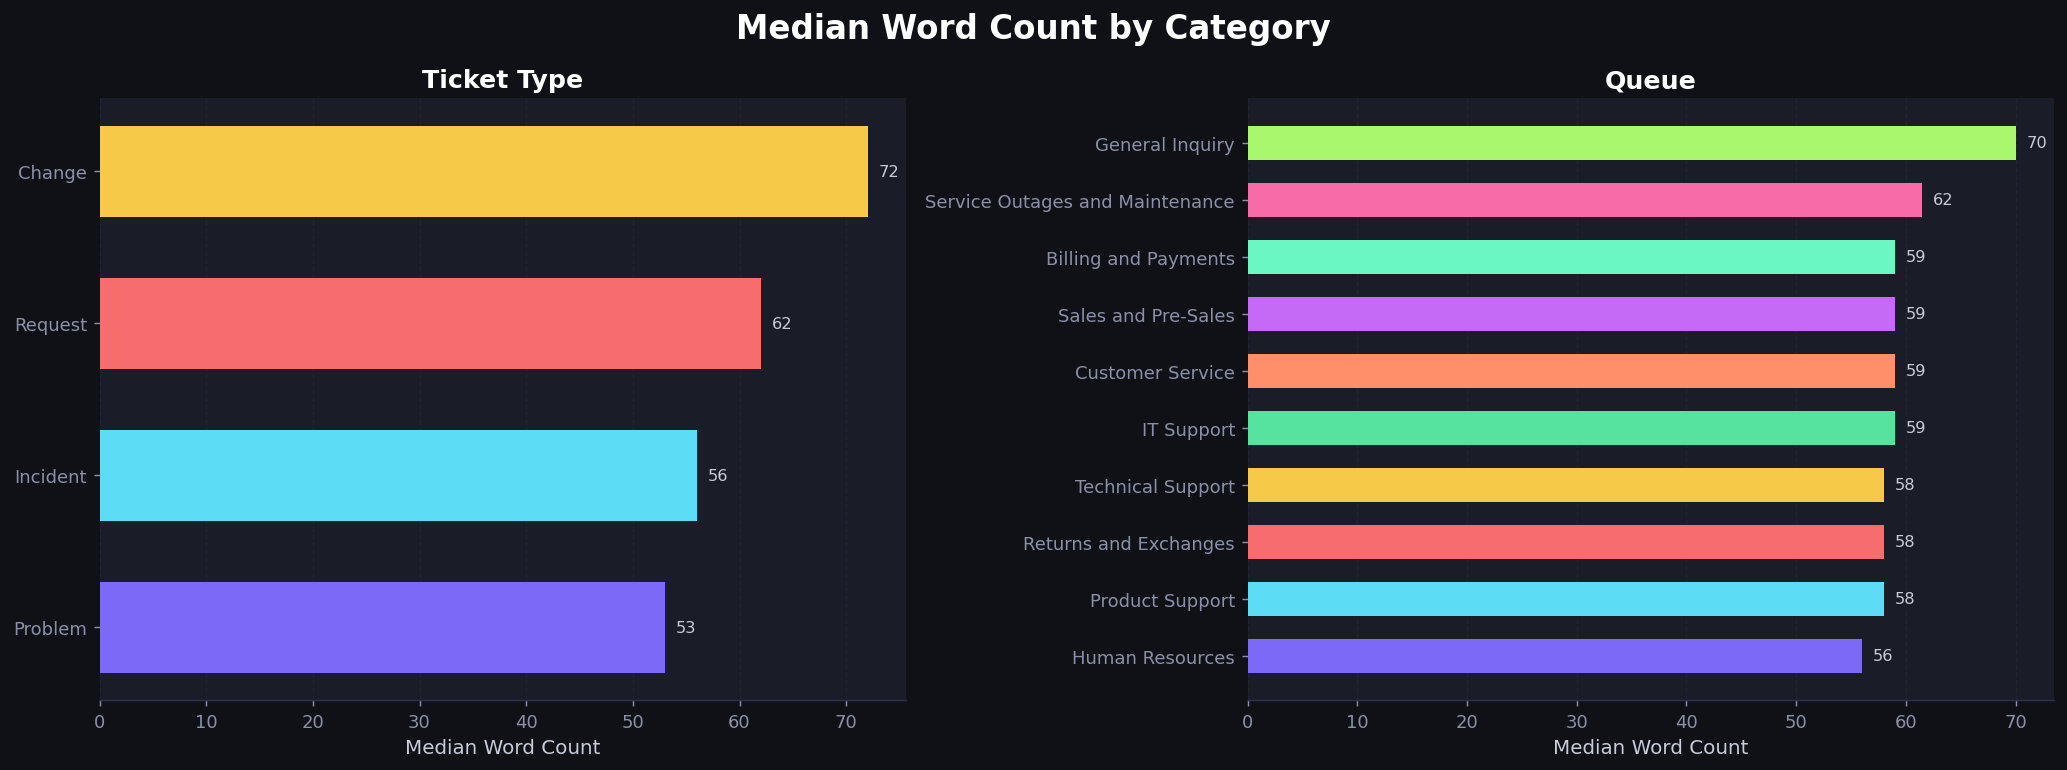

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Median Word Count by Category', fontsize=18, fontweight='bold', color='white')

for ax, col, title in zip(axes, ['type', 'queue'], ['Ticket Type', 'Queue']):
    medians = df.groupby(col)['word_len'].median().sort_values(ascending=True)
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(medians))]

    bars = ax.barh(medians.index, medians.values, color=colors, edgecolor='none', height=0.6)
    for bar, val in zip(bars, medians.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}', va='center', fontsize=9, color='#c8ccd8')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Median Word Count')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_08_median_wordcount.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.10 Final clean dataset summary

In [18]:
print('=' * 55)
print('       FINAL CLEAN DATASET SUMMARY')
print('=' * 55)
print(f'  Rows              : {len(df):,}')
print(f'  Columns           : {df.columns.tolist()}')
print(f'  Unique types      : {df["type"].nunique()} → {df["type"].unique().tolist()}')
print(f'  Unique queues     : {df["queue"].nunique()} → {df["queue"].unique().tolist()}')
print(f'  Avg text words    : {df["word_len"].mean():.0f}')
print(f'  Tickets w/ answer : {df["answer"].notna().sum():,} '
      f'({df["answer"].notna().mean()*100:.1f}%)')
print(f'  Saved to          : {CLEAN_PATH.resolve()}')
print('=' * 55)

       FINAL CLEAN DATASET SUMMARY
  Rows              : 28,587
  Columns           : ['text', 'answer', 'type', 'queue', 'char_len', 'word_len', 'line_len']
  Unique types      : 4 → ['Incident', 'Request', 'Problem', 'Change']
  Unique queues     : 10 → ['Technical Support', 'Returns and Exchanges', 'Billing and Payments', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Product Support', 'IT Support', 'Customer Service', 'Human Resources', 'General Inquiry']
  Avg text words    : 58
  Tickets w/ answer : 28,580 (100.0%)
  Saved to          : C:\Files\Customer Support Ticket System\data\clean.csv
